#**TRANSFORM MODEL**



## **INSTALL AND IMPORT LIBRARIES**



In [ ]:
!pip install yfinance plotly scikit-learn torch -q

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import yfinance as yf
import plotly.graph_objects as go
import plotly.subplots as sp
import os
import copy
from datetime import timedelta
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score
)
from torch.utils.data import DataLoader, TensorDataset

##**CONFIG**

In [ ]:
INPUT_LEN  = 120
OUTPUT_LEN = 5
EPOCHS     = 25
BATCH_SIZE = 64
TICKERS = [
    "RELIANCE.NS","TCS.NS","HDFCBANK.NS","ICICIBANK.NS","KOTAKBANK.NS",
    "SBIN.NS","AXISBANK.NS","BAJFINANCE.NS","BAJAJFINSV.NS","HDFCLIFE.NS",
    "SBILIFE.NS","ITC.NS","HINDUNILVR.NS","NESTLEIND.NS","TATACONSUM.NS",
    "BRITANNIA.NS","ASIANPAINT.NS","ULTRACEMCO.NS","GRASIM.NS","LT.NS",
    "ADANIENT.NS","ADANIPORTS.NS","BHARTIARTL.NS","INDUSINDBK.NS","MARUTI.NS",
    "HEROMOTOCO.NS","EICHERMOT.NS","BAJAJ-AUTO.NS","POWERGRID.NS","NTPC.NS",
    "ONGC.NS","COALINDIA.NS","JSWSTEEL.NS","TATASTEEL.NS","HCLTECH.NS",
    "WIPRO.NS","TECHM.NS","INFY.NS","CIPLA.NS","DRREDDY.NS",
    "APOLLOHOSP.NS","SUNPHARMA.NS","DIVISLAB.NS","LTIM.NS","TITAN.NS",
    "INDIGO.NS","TRENT.NS","JIOFIN.NS"
]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## **DATA PIPELINE**



In [ ]:
ticker_to_id = {t: i for i, t in enumerate(TICKERS)}

class DataPipeline:
    def __init__(self):
        self.scalers  = {}
        self.date_map = {}

    def fetch_data(self, ticker):
        df = yf.download(ticker, period="5y", progress=False)
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        df = df.rename(columns=str.lower)
        df = df[["open", "high", "low", "close", "volume"]]
        return df.dropna()

    def add_features(self, df):
        df = df.copy()
        df["return_1d"]   = df["close"].pct_change()
        df["return_5d"]   = df["close"].pct_change(5)
        df["sma_20"]      = df["close"].rolling(20).mean()
        df["ema_12"]      = df["close"].ewm(span=12).mean()
        df["ema_26"]      = df["close"].ewm(span=26).mean()
        df["macd"]        = df["ema_12"] - df["ema_26"]
        delta = df["close"].diff()
        gain  = delta.clip(lower=0).rolling(14).mean()
        loss  = (-delta.clip(upper=0)).rolling(14).mean()
        rs    = gain / loss.replace(0, np.nan)
        df["rsi"]         = 100 - (100 / (1 + rs))
        std = df["close"].rolling(20).std()
        df["bb_width"]    = (2 * std) / df["sma_20"]
        df["volatility"]  = df["return_1d"].rolling(20).std()
        df["volume_ratio"]= df["volume"] / df["volume"].rolling(20).mean()
        df = df.replace([np.inf, -np.inf], np.nan)
        return df.dropna()

    def create_sequences(self, data, sid):
        X, y, s = [], [], []
        for i in range(len(data) - INPUT_LEN - OUTPUT_LEN):
            X.append(data[i:i + INPUT_LEN])
            y.append(data[i + INPUT_LEN:i + INPUT_LEN + OUTPUT_LEN, 3])
            s.append(sid)
        return np.array(X), np.array(y), np.array(s)

    def prepare(self):
        X_tr, y_tr, s_tr = [], [], []
        X_te, y_te, s_te = [], [], []
        for ticker in TICKERS:
            df  = self.fetch_data(ticker)
            df  = self.add_features(df)
            self.date_map[ticker] = df.index
            scaler = MinMaxScaler()
            scaled = scaler.fit_transform(df.values)
            self.scalers[ticker] = scaler
            X, y, s = self.create_sequences(scaled, ticker_to_id[ticker])
            split = int(len(X) * 0.7)
            X_tr.extend(X[:split]); y_tr.extend(y[:split]); s_tr.extend(s[:split])
            X_te.extend(X[split:]); y_te.extend(y[split:]); s_te.extend(s[split:])
        return {
            "train": (np.array(X_tr), np.array(y_tr), np.array(s_tr)),
            "test":  (np.array(X_te), np.array(y_te), np.array(s_te))
        }

    def prepare_single(self, ticker, fit_scaler=True, scaler=None):
        df = self.fetch_data(ticker)
        df = self.add_features(df)
        self.date_map[ticker] = df.index
        if fit_scaler:
            scaler = MinMaxScaler()
            scaler.fit(df.values)
        self.scalers[ticker] = scaler
        scaled = scaler.transform(df.values)

        X, y, s = self.create_sequences(scaled, sid=0)
        split   = int(len(X) * 0.7)
        return (
            X[:split],  y[:split],
            X[split:],  y[split:],
            df.index
        )

## **MODEL**

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        pe = torch.zeros(500, d_model)
        pos = torch.arange(0, 500).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2) * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.pe = pe.unsqueeze(0)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)].to(x.device)


class Model(nn.Module):
    def __init__(self, input_size, num_stocks):
        super().__init__()
        self.use_embedding = num_stocks > 1
        self.proj  = nn.Linear(input_size, 64)
        self.pos   = PositionalEncoding(64)
        if self.use_embedding:
            self.embed = nn.Embedding(num_stocks, 64)
        enc = nn.TransformerEncoderLayer(d_model=64, nhead=4, batch_first=True)
        self.trans = nn.TransformerEncoder(enc, num_layers=2)
        self.fc    = nn.Linear(64, OUTPUT_LEN)

    def forward(self, x, sid=None):
        x = self.proj(x)
        x = self.pos(x)
        if self.use_embedding and sid is not None:
            x = x + self.embed(sid).unsqueeze(1)
        x = self.trans(x)
        return self.fc(x[:, -1, :])

## **TRAIN MODEL**

In [ ]:
pipeline = DataPipeline()
MODEL_PATH = "nifty50_model.pt"

if os.path.exists(MODEL_PATH):
    print(f"Loading model from {MODEL_PATH} ...")
    checkpoint = torch.load(MODEL_PATH, map_location=device, weights_only=False)
    INPUT_FEATS  = checkpoint["input_size"]
    model        = Model(INPUT_FEATS, len(TICKERS)).to(device)
    model.load_state_dict(checkpoint["model_state"])
    print(f"Model loaded (input_size={INPUT_FEATS})")
    if "scalers" in checkpoint:
        pipeline.scalers  = checkpoint["scalers"]
        pipeline.date_map = checkpoint["date_map"]
        print(" Scalers loaded from checkpoint")
    else:
        print("  No scalers in checkpoint — will re-fetch training data for scalers.")
        print("    (This takes a few minutes but only runs once.)")
        splits = pipeline.prepare()
        X_train = torch.tensor(splits["train"][0], dtype=torch.float32)
        INPUT_FEATS = X_train.shape[2]
else:
    print(" No checkpoint found — training from scratch (this will take a while).")
    print("    Upload your .pt file to skip this step next time.")
    splits  = pipeline.prepare()
    X_train, y_train, s_train = splits["train"]
    INPUT_FEATS = X_train.shape[2]

    X_tr = torch.tensor(X_train, dtype=torch.float32)
    y_tr = torch.tensor(y_train, dtype=torch.float32)
    s_tr = torch.tensor(s_train, dtype=torch.long)
    loader = DataLoader(TensorDataset(X_tr, y_tr, s_tr),
                        batch_size=BATCH_SIZE, shuffle=True)

    model     = Model(INPUT_FEATS, len(TICKERS)).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0003)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3)
    loss_fn   = nn.MSELoss()

    for epoch in range(EPOCHS):
        model.train()
        total = 0
        for xb, yb, sb in loader:
            xb, yb, sb = xb.to(device), yb.to(device), sb.to(device)
            pred = model(xb, sb)
            loss = loss_fn(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total += loss.item()
        avg = total / len(loader)
        scheduler.step(avg)
        print(f"Epoch {epoch+1}/{EPOCHS}: loss={avg:.4f}")

    # Save for next time
    torch.save({
        "model_state": model.state_dict(),
        "input_size":  INPUT_FEATS,
        "scalers":     pipeline.scalers,
        "date_map":    pipeline.date_map,
    }, MODEL_PATH)
    print(f" Model saved to {MODEL_PATH}")
model.eval()
print("Model ready")

Loading model from nifty50_model.pt ...
Model loaded (input_size=15)
 Scalers loaded from checkpoint
Model ready


In [ ]:
from google.colab import files
files.download("nifty50_model.pt")

## **FETCH & PREPARE THE UNSEEN STOCK**

In [ ]:
UNSEEN_TICKER=input("Stock Name:")
print(f"Fetching {UNSEEN_TICKER} ...")
(
    X_unseen_train, y_unseen_train,
    X_unseen_test,  y_unseen_test,
    unseen_dates
) = pipeline.prepare_single(UNSEEN_TICKER)

print(f"{UNSEEN_TICKER} | Train sequences: {len(X_unseen_train)} | Test sequences: {len(X_unseen_test)}")
print(f"   Features per timestep: {X_unseen_test.shape[2]} (expected {INPUT_FEATS})")

assert X_unseen_test.shape[2] == INPUT_FEATS, \
    f"Feature mismatch! Got {X_unseen_test.shape[2]}, expected {INPUT_FEATS}"

Stock Name:DMART.NS
Fetching DMART.NS ...


/tmp/ipykernel_1633/214373137.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="5y", progress=False)


DMART.NS | Train sequences: 763 | Test sequences: 328
   Features per timestep: 15 (expected 15)


## **USING INVERSE TRANSFORM**

In [ ]:
def inverse_close(arr, ticker):
    scaler = pipeline.scalers[ticker]
    dummy  = np.zeros((len(arr), INPUT_FEATS))
    dummy[:, 3] = arr          # col 3 = close
    return scaler.inverse_transform(dummy)[:, 3]

def run_inference(model_to_use, X, emb_override=None):
    model_to_use.eval()
    preds = []

    with torch.no_grad():
        for i in range(len(X)):
            x = torch.tensor(X[i], dtype=torch.float32).unsqueeze(0).to(device)
            if emb_override is not None:

                xp = model_to_use.proj(x)
                xp = model_to_use.pos(xp)
                xp = xp + emb_override.unsqueeze(1).to(device)
                xp = model_to_use.trans(xp)
                out = model_to_use.fc(xp[:, -1, :])
            else:
                out = model_to_use(x)
            preds.append(out.cpu().numpy()[0])
    return np.array(preds)

## **USING FEW SHOT**

In [ ]:
print("FEW-SHOT ADAPTATION")

fs_model = copy.deepcopy(model)
FEWSHOT_EPOCHS = 50
FEWSHOT_LR     = 0.001

# Better embedding init
new_emb_weight = torch.zeros(1, 64)
if model.use_embedding:
    mean_emb = model.embed.weight.mean(dim=0, keepdim=True)
    new_emb_weight = mean_emb.cpu().detach().clone()

unseen_emb = nn.Parameter(new_emb_weight.to(device), requires_grad=True)

# Unfreeze embedding + output head (key fix)
for param in fs_model.parameters():
    param.requires_grad = False

for param in fs_model.fc.parameters():
    param.requires_grad = True

fs_optimizer = torch.optim.Adam(
    [unseen_emb] + list(fs_model.fc.parameters()),
    lr=FEWSHOT_LR
)
fs_loss_fn = nn.MSELoss()

X_fs = torch.tensor(X_unseen_train, dtype=torch.float32)
y_fs = torch.tensor(y_unseen_train, dtype=torch.float32)

# Train/val split for early stopping
val_size = max(1, int(0.1 * len(X_fs)))
X_val, y_val = X_fs[-val_size:].to(device), y_fs[-val_size:].to(device)
X_fs, y_fs   = X_fs[:-val_size], y_fs[:-val_size]

fs_loader = DataLoader(TensorDataset(X_fs, y_fs),
                       batch_size=32, shuffle=True)

# FiLM-style conditioning instead of additive bias
class FiLMEmbed(nn.Module):
    def __init__(self, emb_dim, feat_dim):
        super().__init__()
        self.scale_head = nn.Linear(emb_dim, feat_dim)
        self.shift_head = nn.Linear(emb_dim, feat_dim)

    def forward(self, x, emb):
        # x: (B, T, D), emb: (1, emb_dim)
        scale = self.scale_head(emb).unsqueeze(1)  # (1, 1, D)
        shift = self.shift_head(emb).unsqueeze(1)  # (1, 1, D)
        return x * scale + shift

film = FiLMEmbed(64, fs_model.proj.out_features).to(device)

fs_optimizer = torch.optim.Adam(
    [unseen_emb] + list(fs_model.fc.parameters()) + list(film.parameters()),
    lr=FEWSHOT_LR
)

fs_model.train()
film.train()

best_val_loss = float('inf')
best_emb      = unseen_emb.detach().clone()
patience      = 10
no_improve    = 0

print(f"\nTraining new embedding on {len(X_fs)} sequences for {FEWSHOT_EPOCHS} epochs ...")

for epoch in range(FEWSHOT_EPOCHS):
    fs_model.train()
    film.train()
    total = 0

    for xb, yb in fs_loader:
        xb, yb = xb.to(device), yb.to(device)

        xp   = fs_model.proj(xb)
        xp   = fs_model.pos(xp)
        xp   = film(xp, unseen_emb)          # FiLM conditioning (replaces additive)
        xp   = fs_model.trans(xp)
        pred = fs_model.fc(xp[:, -1, :])
        loss = fs_loss_fn(pred, yb)

        fs_optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(fs_model.fc.parameters()) + list(film.parameters()), 1.0
        )
        fs_optimizer.step()
        total += loss.item()

    # Validation
    fs_model.eval()
    film.eval()
    with torch.no_grad():
        xp_v   = fs_model.proj(X_val)
        xp_v   = fs_model.pos(xp_v)
        xp_v   = film(xp_v, unseen_emb)
        xp_v   = fs_model.trans(xp_v)
        pred_v = fs_model.fc(xp_v[:, -1, :])
        val_loss = fs_loss_fn(pred_v, y_val).item()

    print(f"  Epoch {epoch+1:>2}/{FEWSHOT_EPOCHS} | train={total/len(fs_loader):.5f} | val={val_loss:.5f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_emb      = unseen_emb.detach().clone()
        best_fc       = copy.deepcopy(fs_model.fc.state_dict())
        best_film     = copy.deepcopy(film.state_dict())
        no_improve    = 0
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"  Early stopping at epoch {epoch+1}")
            break

# Restore best checkpoint
unseen_emb = nn.Parameter(best_emb.to(device), requires_grad=False)
fs_model.fc.load_state_dict(best_fc)
film.load_state_dict(best_film)

# Inference — you'll need to pass film into run_inference or inline it:
fs_model.eval()
film.eval()

X_test_t = torch.tensor(X_unseen_test, dtype=torch.float32).to(device)
with torch.no_grad():
    xp   = fs_model.proj(X_test_t)
    xp   = fs_model.pos(xp)
    xp   = film(xp, unseen_emb)
    xp   = fs_model.trans(xp)
    fs_preds_scaled = fs_model.fc(xp[:, -1, :]).cpu().numpy()

fs_actual = inverse_close(y_unseen_test[:, 0], UNSEEN_TICKER)
fs_pred   = inverse_close(fs_preds_scaled[:, 0], UNSEEN_TICKER)

fs_rmse = np.sqrt(mean_squared_error(fs_actual, fs_pred))
fs_mae  = mean_absolute_error(fs_actual, fs_pred)
fs_r2   = r2_score(fs_actual, fs_pred)
fs_mape = np.mean(np.abs((fs_actual - fs_pred) / fs_actual)) * 100

print(f"\nFew-Shot Metrics — {UNSEEN_TICKER}")
print(f"  MAPE  : {fs_mape:.2f}%")
print(f"  RMSE  : ₹{fs_rmse:.2f}")
print(f"  MAE   : ₹{fs_mae:.2f}")
print(f"  R²    : {fs_r2:.4f}")

FEW-SHOT ADAPTATION

Training new embedding on 687 sequences for 50 epochs ...
  Epoch  1/50 | train=0.03425 | val=0.06385
  Epoch  2/50 | train=0.01747 | val=0.06372
  Epoch  3/50 | train=0.01033 | val=0.02844
  Epoch  4/50 | train=0.00648 | val=0.02187
  Epoch  5/50 | train=0.00513 | val=0.01205
  Epoch  6/50 | train=0.00470 | val=0.00885
  Epoch  7/50 | train=0.00427 | val=0.00926
  Epoch  8/50 | train=0.00464 | val=0.00741
  Epoch  9/50 | train=0.00404 | val=0.01203
  Epoch 10/50 | train=0.00410 | val=0.00862
  Epoch 11/50 | train=0.00357 | val=0.00739
  Epoch 12/50 | train=0.00346 | val=0.00720
  Epoch 13/50 | train=0.00411 | val=0.00925
  Epoch 14/50 | train=0.00381 | val=0.00712
  Epoch 15/50 | train=0.00360 | val=0.00734
  Epoch 16/50 | train=0.00342 | val=0.00987
  Epoch 17/50 | train=0.00377 | val=0.00940
  Epoch 18/50 | train=0.00448 | val=0.00892
  Epoch 19/50 | train=0.00339 | val=0.00852
  Epoch 20/50 | train=0.00359 | val=0.00840
  Epoch 21/50 | train=0.00315 | val=0.006

## **FUTURE FORECAST/PREDICTION**

In [ ]:
print(f" Forecasting next {OUTPUT_LEN} trading days for {UNSEEN_TICKER} ...\n")

last_seq = torch.tensor(X_unseen_test[-1], dtype=torch.float32).unsqueeze(0).to(device)

fs_model.eval()
with torch.no_grad():
    xp   = fs_model.proj(last_seq)
    xp   = fs_model.pos(xp)
    xp   = xp + unseen_emb.detach().unsqueeze(1)
    xp   = fs_model.trans(xp)
    fut_scaled = fs_model.fc(xp[:, -1, :]).cpu().numpy()[0]

fut_prices   = inverse_close(fut_scaled, UNSEEN_TICKER)
last_date    = unseen_dates[-1]
future_dates = [last_date + timedelta(days=i+1) for i in range(OUTPUT_LEN)]

print(f"Last known close: ₹{fs_actual[-1]:.2f}  (date: {last_date.date()})")
print()
for d, p in zip(future_dates, fut_prices):
    change = ((p - fs_actual[-1]) / fs_actual[-1]) * 100
    print(f"  {d.date()}  →  ₹{p:.2f}")


N_plot_hist = 30


plot_actual_dates = unseen_dates[-N_plot_hist:]
plot_actual_prices = fs_actual[-N_plot_hist:]
plot_predicted_prices = fs_pred[-N_plot_hist:]


forecast_start_date = unseen_dates[-1]
forecast_start_price = fs_pred[-1]

forecast_dates_combined = [forecast_start_date] + future_dates
forecast_prices_combined = [forecast_start_price] + list(fut_prices)

fig = go.Figure()


fig.add_trace(go.Scatter(
    x=plot_actual_dates, y=plot_actual_prices,
    name="Actual Prices", mode="lines",
    line=dict(color="#00E5FF", width=2)
))

fig.add_trace(go.Scatter(
    x=plot_actual_dates, y=plot_predicted_prices,
    name="Few-Shot Predicted Prices", mode="lines",
    line=dict(color="#69FF47", width=2)
))


fig.add_trace(go.Scatter(
    x=forecast_dates_combined,
    y=forecast_prices_combined,
    name=f"{OUTPUT_LEN}-Day Future Forecast", mode="lines",
    line=dict(color="#FFD700", width=2, dash='dot'),
    marker=dict(size=6, symbol='circle')
))

fig.update_layout(
    title=f"{UNSEEN_TICKER} - Last {N_plot_hist} Days and {OUTPUT_LEN}-Day Forecast",
    xaxis_title="Date",
    yaxis_title="Close Price (₹)",
    template="plotly_dark",
    legend=dict(x=1.02, y=1, xanchor='left', yanchor='top')
)

fig.show()

 Forecasting next 5 trading days for DMART.NS ...

Last known close: ₹4628.50  (date: 2026-04-24)

  2026-04-25  →  ₹4356.33
  2026-04-26  →  ₹4325.65
  2026-04-27  →  ₹4302.34
  2026-04-28  →  ₹4310.65
  2026-04-29  →  ₹4309.03


## **MULTIPLE UNSEEN STOCK**


 Processing PIDILITIND.NS ...


/tmp/ipykernel_1633/214373137.py:9: FutureWarning:

YF.download() has changed argument auto_adjust default to True



  Few-shot: 788 adapt / 140 val / 164 test seqs
    Epoch  10 | train=0.00466 | val=0.01592 | patience=1
    Epoch  20 | train=0.00264 | val=0.00301 | patience=0
    Epoch  30 | train=0.00239 | val=0.00318 | patience=8
    Early stop at epoch 32

  ✅ PIDILITIND.NS | MAPE=1.52% | RMSE=₹29.29 | R²=0.7876


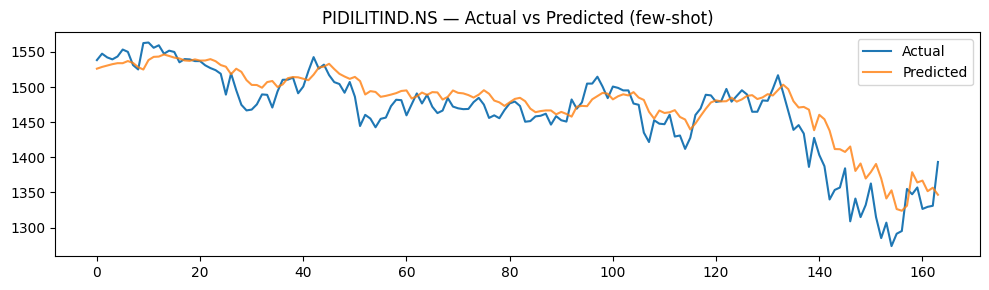


 Processing HAVELLS.NS ...


/tmp/ipykernel_1633/214373137.py:9: FutureWarning:

YF.download() has changed argument auto_adjust default to True



  Few-shot: 788 adapt / 140 val / 164 test seqs
    Epoch  10 | train=0.00503 | val=0.07391 | patience=8
    Early stop at epoch 12

  ✅ HAVELLS.NS | MAPE=4.97% | RMSE=₹84.98 | R²=0.2437


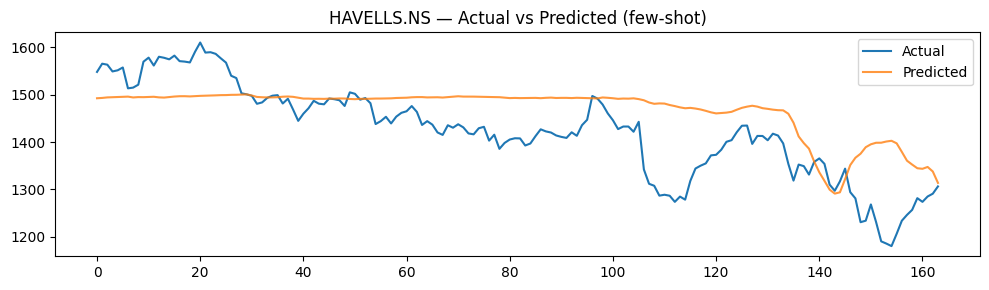


 Processing DABUR.NS ...


/tmp/ipykernel_1633/214373137.py:9: FutureWarning:

YF.download() has changed argument auto_adjust default to True



  Few-shot: 788 adapt / 140 val / 164 test seqs
    Epoch  10 | train=0.00597 | val=0.07290 | patience=5
    Epoch  20 | train=0.00378 | val=0.04433 | patience=4
    Epoch  30 | train=0.00330 | val=0.03753 | patience=6
    Epoch  40 | train=0.00307 | val=0.03126 | patience=0
    Epoch  50 | train=0.00282 | val=0.03305 | patience=10
    Early stop at epoch 50

  ✅ DABUR.NS | MAPE=6.99% | RMSE=₹40.33 | R²=-0.6228


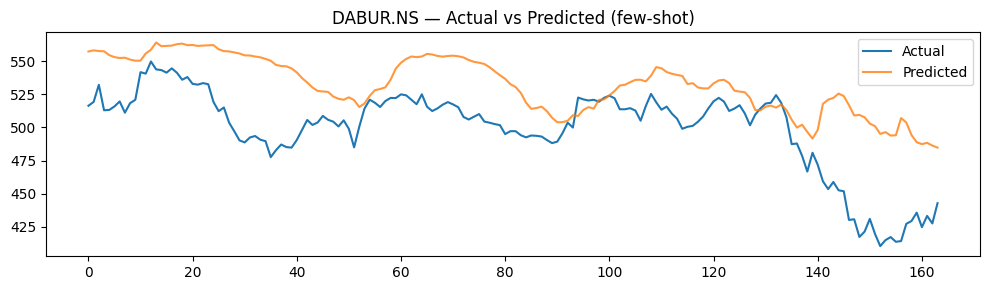


Batch Few-Shot Results
       Ticker  MAPE %      R²
PIDILITIND.NS    1.52  0.7876
   HAVELLS.NS    4.97  0.2437
     DABUR.NS    6.99 -0.6228


In [ ]:
BATCH_UNSEEN = ["PIDILITIND.NS", "HAVELLS.NS", "DABUR.NS"]
BATCH_UNSEEN = [t for t in BATCH_UNSEEN if t not in TICKERS]

FS_EPOCHS    = 60
FS_LR        = 1e-4        # very small — fine-tuning whole model
FS_BATCH     = 16
FS_PATIENCE  = 10
FS_SPLIT     = 0.85

class FiLMEmbed(nn.Module):
    def __init__(self, emb_dim, feat_dim):
        super().__init__()
        self.scale_head = nn.Linear(emb_dim, feat_dim)
        self.shift_head = nn.Linear(emb_dim, feat_dim)
        nn.init.ones_(self.scale_head.weight)
        nn.init.zeros_(self.scale_head.bias)
        nn.init.zeros_(self.shift_head.weight)
        nn.init.zeros_(self.shift_head.bias)

    def forward(self, x, emb):
        scale = self.scale_head(emb).unsqueeze(1)
        shift = self.shift_head(emb).unsqueeze(1)
        return x * scale + shift


D_MODEL = model.proj.out_features
EMB_DIM = model.embed.weight.shape[1] if model.use_embedding else 64

results = []

for t in BATCH_UNSEEN:
    print(f"\n{'='*55}")
    print(f" Processing {t} ...")
    try:
        # ── 1. Fetch & scale ───────────────────────────────────
        df_t     = pipeline.fetch_data(t)
        df_t     = pipeline.add_features(df_t)
        pipeline.date_map[t] = df_t.index

        sc_t = MinMaxScaler()
        sc_t.fit(df_t.values)
        pipeline.scalers[t] = sc_t
        scaled_t = sc_t.transform(df_t.values)

        X_t, y_t, _ = pipeline.create_sequences(scaled_t, sid=0)
        split        = int(len(X_t) * FS_SPLIT)
        X_tr_t, y_tr_t = X_t[:split], y_t[:split]
        X_te_t, y_te_t = X_t[split:], y_t[split:]

        if len(X_te_t) < 10:
            print("  Not enough test data, skipping.")
            continue

        # ── 2. Full fine-tune with differential learning rates ──
        fs_m = copy.deepcopy(model)

        # Learnable stock embedding
        if model.use_embedding:
            init_emb = model.embed.weight.mean(dim=0, keepdim=True).detach().clone()
        else:
            init_emb = torch.zeros(1, EMB_DIM)
        unseen_emb = nn.Parameter(init_emb.to(device), requires_grad=True)

        film = FiLMEmbed(EMB_DIM, D_MODEL).to(device)

        # Differential LRs — lower for early layers, higher for head
        # This preserves general patterns while adapting to new stock
        param_groups = [
            {"params": [unseen_emb],                          "lr": FS_LR * 5.0},
            {"params": list(film.parameters()),               "lr": FS_LR * 5.0},
            {"params": list(fs_m.proj.parameters()),          "lr": FS_LR * 0.1},
            {"params": list(fs_m.trans.parameters()),         "lr": FS_LR * 0.5},
            {"params": list(fs_m.fc.parameters()),            "lr": FS_LR * 2.0},
        ]
        if hasattr(fs_m, 'pos') and hasattr(fs_m.pos, 'parameters'):
            param_groups.append(
                {"params": list(fs_m.pos.parameters()),       "lr": FS_LR * 0.1}
            )

        fs_opt = torch.optim.AdamW(param_groups, weight_decay=1e-3)
        fs_sch = torch.optim.lr_scheduler.CosineAnnealingLR(
            fs_opt, T_max=FS_EPOCHS, eta_min=1e-6
        )

        X_fs = torch.tensor(X_tr_t, dtype=torch.float32)
        y_fs = torch.tensor(y_tr_t, dtype=torch.float32)

        val_cut      = int(len(X_fs) * 0.85)
        X_ftr, y_ftr = X_fs[:val_cut], y_fs[:val_cut]
        X_fva, y_fva = X_fs[val_cut:].to(device), y_fs[val_cut:].to(device)

        loader_fs = DataLoader(
            TensorDataset(X_ftr, y_ftr),
            batch_size=FS_BATCH, shuffle=True, drop_last=False
        )

        best_val, patience_cnt, best_state = 1e9, 0, None
        print(f"  Few-shot: {len(X_ftr)} adapt / {len(X_fva)} val / {len(X_te_t)} test seqs")

        for epoch in range(FS_EPOCHS):
            fs_m.train()
            film.train()
            total = 0

            for xb, yb in loader_fs:
                xb, yb = xb.to(device), yb.to(device)

                xp   = fs_m.proj(xb)
                xp   = fs_m.pos(xp)
                xp   = film(xp, unseen_emb)
                xp   = fs_m.trans(xp)
                pred = fs_m.fc(xp[:, -1, :])
                loss = nn.functional.mse_loss(pred, yb)

                fs_opt.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    [p for g in param_groups for p in g["params"]], 1.0
                )
                fs_opt.step()
                total += loss.item()

            fs_sch.step()

            fs_m.eval()
            film.eval()
            with torch.no_grad():
                xp = fs_m.proj(X_fva)
                xp = fs_m.pos(xp)
                xp = film(xp, unseen_emb)
                xp = fs_m.trans(xp)
                vp = fs_m.fc(xp[:, -1, :])
                val_loss = nn.functional.mse_loss(vp, y_fva).item()

            if val_loss < best_val - 1e-6:
                best_val     = val_loss
                patience_cnt = 0
                best_state   = {
                    "emb":   unseen_emb.detach().clone(),
                    "film":  copy.deepcopy(film.state_dict()),
                    "model": copy.deepcopy(fs_m.state_dict()),
                }
            else:
                patience_cnt += 1

            if (epoch + 1) % 10 == 0:
                print(f"    Epoch {epoch+1:3d} | train={total/len(loader_fs):.5f} | val={val_loss:.5f} | patience={patience_cnt}")

            if patience_cnt >= FS_PATIENCE:
                print(f"    Early stop at epoch {epoch+1}")
                break

        # ── Restore best checkpoint ────────────────────────────
        if best_state is not None:
            unseen_emb = nn.Parameter(best_state["emb"].to(device), requires_grad=False)
            film.load_state_dict(best_state["film"])
            fs_m.load_state_dict(best_state["model"])

        # ── Inference ──────────────────────────────────────────
        fs_m.eval()
        film.eval()
        X_te_tensor = torch.tensor(X_te_t, dtype=torch.float32).to(device)

        with torch.no_grad():
            xp = fs_m.proj(X_te_tensor)
            xp = fs_m.pos(xp)
            xp = film(xp, unseen_emb)
            xp = fs_m.trans(xp)
            preds_scaled = fs_m.fc(xp[:, -1, :]).cpu().numpy()

        act  = inverse_close(y_te_t[:, 0], t)
        pre  = inverse_close(preds_scaled[:, 0], t)
        mape = np.mean(np.abs((act - pre) / act)) * 100
        r2   = r2_score(act, pre)
        rmse = np.sqrt(mean_squared_error(act, pre))

        results.append({"Ticker": t, "MAPE %": round(mape, 2), "R²": round(r2, 4)})
        print(f"\n  ✅ {t} | MAPE={mape:.2f}% | RMSE=₹{rmse:.2f} | R²={r2:.4f}")

        # ── Quick sanity plot ──────────────────────────────────
        plt.figure(figsize=(10, 3))
        plt.plot(act, label="Actual")
        plt.plot(pre, label="Predicted", alpha=0.8)
        plt.title(f"{t} — Actual vs Predicted (few-shot)")
        plt.legend()
        plt.tight_layout()
        plt.show()

    except Exception as e:
        import traceback
        print(f"  ❌ {t}: {e}")
        traceback.print_exc()

if results:
    print("\nBatch Few-Shot Results")
    print(pd.DataFrame(results).to_string(index=False))
else:
    print("No batch results.")

In [ ]:
for res_dict in results:  # Iterate over the results list
    print(f"\n{res_dict['Ticker']}")
    print(f"  MAPE  : {res_dict['MAPE %']:.2f}%")
    print(f"  R²    : {res_dict['R²']:.4f}")
    # Note: 'act', 'pre' (actual/predicted arrays) and 'best_val' (validation loss)
    # are not stored in the 'results' list, so their specific statistics cannot be printed here.
    # Only the metrics (MAPE, R²) stored in 'results' can be displayed per ticker.


PIDILITIND.NS
  MAPE  : 1.52%
  R²    : 0.7876

HAVELLS.NS
  MAPE  : 4.97%
  R²    : 0.2437

DABUR.NS
  MAPE  : 6.99%
  R²    : -0.6228


  act  — mean=499.18  std=31.66  min=410.45  max=549.80
  pred — mean=532.12  std=21.00  min=484.79  max=564.13
  scaled pred — mean=0.4994  std=0.0862
  scaled act  — mean=0.3642        std=0.1300
  scaler data_min=412.45  data_max=655.83


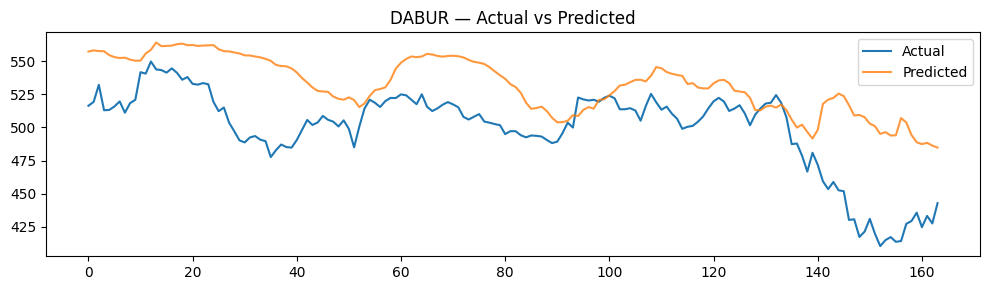

In [ ]:
if t == "DABUR.NS":
    print(f"  act  — mean={act.mean():.2f}  std={act.std():.2f}  min={act.min():.2f}  max={act.max():.2f}")
    print(f"  pred — mean={pre.mean():.2f}  std={pre.std():.2f}  min={pre.min():.2f}  max={pre.max():.2f}")

    # Check what scaled predictions look like BEFORE inverse_close
    print(f"  scaled pred — mean={preds_scaled[:,0].mean():.4f}  std={preds_scaled[:,0].std():.4f}")
    print(f"  scaled act  — mean={y_te_t[:,0].mean():.4f}        std={y_te_t[:,0].std():.4f}")

    # Check the scaler min/max for close price
    close_idx = 0  # assuming close is column 0
    sc = pipeline.scalers[t]
    print(f"  scaler data_min={sc.data_min_[close_idx]:.2f}  data_max={sc.data_max_[close_idx]:.2f}")

    plt.figure(figsize=(10,3))
    plt.plot(act, label="Actual")
    plt.plot(pre, label="Predicted", alpha=0.8)
    plt.title("DABUR — Actual vs Predicted")
    plt.legend(); plt.tight_layout(); plt.show()

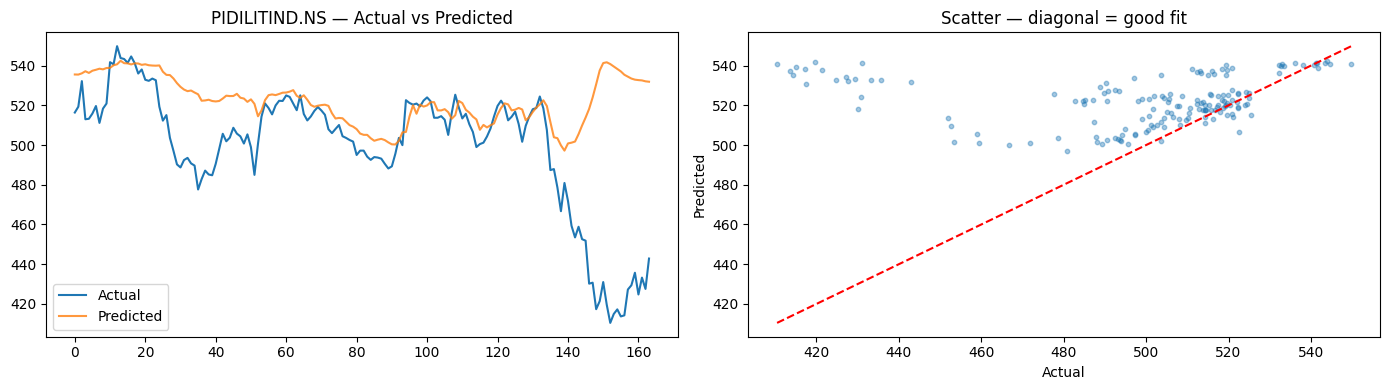

  corr(actual, pred shifted by -1): 0.0321
  corr(actual, pred shifted by -2): 0.0439
  corr(actual, pred shifted by -3): 0.0536
  corr(actual, pred shifted by -4): 0.0671
  corr(actual, pred shifted by -5): 0.0865
  corr(actual, pred no shift)        : 0.0250


In [ ]:
import matplotlib.pyplot as plt
# Run this BEFORE changing anything else
t = "PIDILITIND.NS"

# Get predictions from your last run (rerun inference for t)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Plot 1: Actual vs Predicted over time
axes[0].plot(act, label="Actual", linewidth=1.5)
axes[0].plot(pre, label="Predicted", linewidth=1.5, alpha=0.8)
axes[0].set_title(f"{t} — Actual vs Predicted")
axes[0].legend()

# Plot 2: Scatter — if diagonal = good, if horizontal blob = mean prediction
axes[1].scatter(act, pre, alpha=0.4, s=10)
axes[1].plot([act.min(), act.max()], [act.min(), act.max()], 'r--')
axes[1].set_xlabel("Actual")
axes[1].set_ylabel("Predicted")
axes[1].set_title("Scatter — diagonal = good fit")

plt.tight_layout()
plt.show()

# Print lag correlation — tells you if predictions are just shifted by 1 step
for lag in range(1, 6):
    shifted = np.corrcoef(act[lag:], pre[:-lag])[0,1]
    print(f"  corr(actual, pred shifted by -{lag}): {shifted:.4f}")
corr_0 = np.corrcoef(act, pre)[0,1]
print(f"  corr(actual, pred no shift)        : {corr_0:.4f}")

## **MULTIPLE UNSEEN STOCK FUTURE FORECAST/PREDICTION**

In [ ]:
print(f" Forecasting next {OUTPUT_LEN} trading days for stocks in BATCH_UNSEEN ...\n")
if 'mean_emb' not in globals() and model.use_embedding:
    mean_emb = model.embed.weight.mean(dim=0, keepdim=True).cpu().detach().clone()
elif not model.use_embedding:
    mean_emb = None

for current_ticker in BATCH_UNSEEN:
    print(f"\n--- Processing {current_ticker} ---")
    try:
        (
            X_curr_train, y_curr_train,
            X_curr_test,  y_curr_test,
            curr_dates
        ) = pipeline.prepare_single(current_ticker, fit_scaler=True)

        if len(X_curr_test) < 10:
            print(f"  Not enough data for {current_ticker}, skipping.")
            continue

        zs_preds_scaled = run_inference(model, X_curr_test, emb_override=mean_emb)
        zs_actual = inverse_close(y_curr_test[:, 0], current_ticker)
        zs_pred   = inverse_close(zs_preds_scaled[:, 0], current_ticker)

        zs_mape = np.mean(np.abs((zs_actual - zs_pred) / zs_actual)) * 100
        zs_r2   = r2_score(zs_actual, zs_pred)
        print(f"  Zero-Shot Metrics — {current_ticker}")
        print(f"    MAPE  : {zs_mape:.2f}%")
        print(f"    R²    : {zs_r2:.4f}")


        last_seq_curr = torch.tensor(X_curr_test[-1], dtype=torch.float32).unsqueeze(0).to(device)

        model.eval()
        with torch.no_grad():
            xp   = model.proj(last_seq_curr)
            xp   = model.pos(xp)

            if mean_emb is not None:
                xp   = xp + mean_emb.unsqueeze(1).to(device)
            xp   = model.trans(xp)
            fut_scaled_curr = model.fc(xp[:, -1, :]).cpu().numpy()[0]

        fut_prices_curr = inverse_close(fut_scaled_curr, current_ticker)
        last_date_curr    = curr_dates[-1]
        future_dates_curr = [last_date_curr + timedelta(days=i+1) for i in range(OUTPUT_LEN)]

        print(f"  Last known close: ₹{zs_actual[-1]:.2f}  (date: {last_date_curr.date()})")
        print("  Future Forecast:")
        for d, p in zip(future_dates_curr, fut_prices_curr):
            print(f"    {d.date()}  →  ₹{p:.2f}")

        N_plot_hist = 30

        plot_actual_dates = curr_dates[-N_plot_hist:]
        plot_actual_prices = zs_actual[-N_plot_hist:]
        plot_predicted_prices = zs_pred[-N_plot_hist:]

        forecast_start_date = curr_dates[-1]
        forecast_start_price = zs_pred[-1]

        forecast_dates_combined = [forecast_start_date] + future_dates_curr
        forecast_prices_combined = [forecast_start_price] + list(fut_prices_curr)

        fig = go.Figure()

        fig.add_trace(go.Scatter(
            x=plot_actual_dates, y=plot_actual_prices,
            name="Actual Prices", mode="lines",
            line=dict(color="#00E5FF", width=2)
        ))

        fig.add_trace(go.Scatter(
            x=plot_actual_dates, y=plot_predicted_prices,
            name="Zero-Shot Predicted Prices", mode="lines",
            line=dict(color="#69FF47", width=2)
        ))

        fig.add_trace(go.Scatter(
            x=forecast_dates_combined,
            y=forecast_prices_combined,
            name=f"{OUTPUT_LEN}-Day Future Forecast", mode="lines",
            line=dict(color="#FFD700", width=2, dash='dot'),
            marker=dict(size=6, symbol='circle')
        ))

        fig.update_layout(
            title=f"{current_ticker} - Last {N_plot_hist} Days and {OUTPUT_LEN}-Day Forecast (Zero-Shot)",
            xaxis_title="Date",
            yaxis_title="Close Price (₹)",
            template="plotly_dark",
            legend=dict(x=1.02, y=1, xanchor='left', yanchor='top')
        )
        fig.show()

    except Exception as e:
        print(f"  Error processing {current_ticker}: {e}")

 Forecasting next 5 trading days for stocks in BATCH_UNSEEN ...


--- Processing PIDILITIND.NS ---


/tmp/ipykernel_1633/214373137.py:9: FutureWarning:

YF.download() has changed argument auto_adjust default to True



  Zero-Shot Metrics — PIDILITIND.NS
    MAPE  : 6.16%
    R²    : -1.7221
  Last known close: ₹1393.40  (date: 2026-04-24)
  Future Forecast:
    2026-04-25  →  ₹1490.78
    2026-04-26  →  ₹1490.69
    2026-04-27  →  ₹1490.91
    2026-04-28  →  ₹1490.82
    2026-04-29  →  ₹1492.80



--- Processing HAVELLS.NS ---


/tmp/ipykernel_1633/214373137.py:9: FutureWarning:

YF.download() has changed argument auto_adjust default to True



  Zero-Shot Metrics — HAVELLS.NS
    MAPE  : 9.11%
    R²    : -1.2574
  Last known close: ₹1306.40  (date: 2026-04-24)
  Future Forecast:
    2026-04-25  →  ₹1394.60
    2026-04-26  →  ₹1394.69
    2026-04-27  →  ₹1394.51
    2026-04-28  →  ₹1395.78
    2026-04-29  →  ₹1396.52



--- Processing DABUR.NS ---


/tmp/ipykernel_1633/214373137.py:9: FutureWarning:

YF.download() has changed argument auto_adjust default to True



  Zero-Shot Metrics — DABUR.NS
    MAPE  : 4.59%
    R²    : -0.0721
  Last known close: ₹442.85  (date: 2026-04-24)
  Future Forecast:
    2026-04-25  →  ₹455.84
    2026-04-26  →  ₹455.90
    2026-04-27  →  ₹456.21
    2026-04-28  →  ₹456.42
    2026-04-29  →  ₹456.42
